In [1]:
import wandb

In [2]:
import os
import gc
import sys
import time

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

import pyro
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

In [3]:
sys.path.append('../')
sys.path.append('../util')
sys.path.append('../models')

# LYNX imports
import IO, plot, utils, trajectory, metrics
import vgae, configs, dataset
from importlib import reload

[2025-04-02 16:46:22] cffi mode is CFFI_MODE.ANY
[2025-04-02 16:46:22] R home found: /usr/lib/R
[2025-04-02 16:46:22] R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/cv2/../../lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64
[2025-04-02 16:46:22] LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/cv2/../../lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64
[2025-04-02 16:46:22] Default options to initialize R: rpy2, --quiet, --no-save
[2025-04-02 16:46:23] R is already initialized. No need to initialize.


### Utils

In [4]:
from scipy.spatial import cKDTree

def correct_mislabel_veins(adata, use_rep='ab_label', k=10):
    spatial_coords = adata.obsm["spatial"]
    labels = adata.obs[use_rep].values

    # Get indices for each label
    idx_label_1 = np.where(labels == 1)[0]
    idx_label_2 = np.where(labels == 2)[0]
    idx_label_3 = np.where(labels == 3)[0]

    # Build KD-trees for fast nearest-neighbor search
    tree_label_1 = cKDTree(spatial_coords[idx_label_1])
    tree_label_2 = cKDTree(spatial_coords[idx_label_2])

    # Find average distances from each label 3 cell to label 1 and label 2
    d1, _ = tree_label_1.query(spatial_coords[idx_label_3], k=k, workers=-1)
    d2, _ = tree_label_2.query(spatial_coords[idx_label_3], k=k, workers=-1)

    avg_d1 = d1.mean(axis=1)
    avg_d2 = d2.mean(axis=1)

    # Identify mislabeled 3s where avg distance to 1 is smaller than to 2
    mislabeled = avg_d1 < avg_d2
    labels[idx_label_3[mislabeled]] = 0  # Correct misclassified labels

    # Denoise
    labels = adata.obs[use_rep].values

    # Get indices for labels 0 & 3
    idx_label_0 = np.where(labels == 0)[0]
    idx_label_3 = np.where(labels == 3)[0]
    idx_0_3 = np.concatenate([idx_label_0, idx_label_3])  # Only process 0 & 3

    # Build KD-tree for spatial queries
    tree = cKDTree(spatial_coords)

    # Query nearest neighbors (excluding self)
    _, neighbors = tree.query(spatial_coords[idx_0_3], k=k+1, workers=-1)  # k+1 to exclude self

    # Count majority labels in neighbors
    for i, idx in enumerate(idx_0_3):
        neighbor_labels = labels[neighbors[i, 1:]]  # Exclude self
        majority_label = np.bincount(neighbor_labels).argmax()  # Most frequent label

        # Only update if the majority is different from the current label
        if majority_label in {0, 3} and majority_label != labels[idx]:
            labels[idx] = majority_label

    # Update AnnData object
    adata.obs[use_rep] = labels
    adata.obs[use_rep] = adata.obs[use_rep].astype('category')
    return None

def calculate_vein_axis(
    adata, use_rep='ab_label', 
    w1=.5, w2=.5, 
    vmin=0., vmax=1., k=10
):
    r"""Approx. annotation of PV -> CV axis from only antibody imaging"""
    # Extract spatial coordinates
    coords = adata.obsm['spatial']

    # Identify indices for each structure
    cv_indices = np.where(adata.obs[use_rep] == 0)[0]
    pp_indices = np.where(adata.obs[use_rep] == 2)[0]
    pv_indices = np.where(adata.obs[use_rep] == 3)[0]

    # Build KD-Trees for each structure
    cv_tree = cKDTree(coords[cv_indices])
    pp_tree = cKDTree(coords[pp_indices])
    pv_tree = cKDTree(coords[pv_indices])

    # Initialize array to hold PV-CV values
    axis_values = np.zeros(coords.shape[0])

    # Calculate mean distances to each structure
    for i, point in enumerate(coords):
        d_cv, _ = cv_tree.query(point, k=k)
        d_pp, _ = pp_tree.query(point, k=k)
        d_pv, _ = pv_tree.query(point, k=k)

        mu_cv = np.mean(d_cv)
        mu_pp = np.mean(d_pp)
        mu_pv = np.mean(d_pv)

        # Calculate H1(Medulla vs. Cortex) & H2 (Cortex vs. Capsule)
        H1 = (mu_pp - mu_pv) / (mu_pp + mu_pv)
        H2 = (mu_cv - mu_pp) / (mu_cv + mu_pp)

        # Combine H1 and H2 to get CMA value
        axis_values[i] = w1 * H1 + w2 * H2

    # Rescale to [vmin, vmax]
    axis_min, axis_max = np.min(axis_values), np.max(axis_values)
    axis_values = vmin + (axis_values - axis_min) * ((vmax-vmin) / (axis_max-axis_min))

    adata.obs['t'] = 1.0 - axis_values   # PV (0) --> CV (1)
    return None

### Load data

In [5]:
# Load paired Xenium & DESI
xenium_path = '../../liver3d_bucket/Xenium example /processed'
desi_path = '../../liver3d_bucket/DESI/processed'
sample_id = 'NIH_F5'

adata_xenium = IO.load_xenium(os.path.join(xenium_path, sample_id))
adata_desi = sc.read_h5ad(os.path.join(desi_path, sample_id+'.h5'))
adata_xenium, adata_desi = IO.filter_cells(adata_xenium, adata_desi, by='map')

/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/pandas/core/frame.py:6230: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  new_obj.index = new_index
/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [6]:
if 'cell_type' in adata_xenium.obs.keys():
    adata_xenium.obs['leiden'], categories = adata_xenium.obs.cell_type.factorize()
    categories = categories.values
else:
    adata_norm = adata_xenium.copy()
    sc.pp.normalize_total(adata_norm)
    sc.pp.log1p(adata_norm)

    sc.pp.pca(adata_norm)
    sc.pp.neighbors(adata_norm)
    sc.tl.leiden(adata_norm, random_state=42)
    adata_xenium.obs['leiden'] = adata_norm.obs['leiden'].copy()
    del adata_norm   

/var/tmp/ipykernel_11664/3154631353.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_xenium.obs['leiden'], categories = adata_xenium.obs.cell_type.factorize()


In [7]:
# load antibody validation
ab_path = '../../data/antibody'
sample_id = 'NIH_F5'

adata_ab = IO.load_ab_stain(
    os.path.join(ab_path, sample_id+'.ome.tif'),
    adata_ref=adata_xenium
)

In [8]:
# Normalize to [0, 1] per channel
scaled_chans = np.zeros_like(adata_ab.X)
for i, chan in enumerate(adata_ab.X.T):
    chan = (chan-chan.min()) / (chan.max()-chan.min())
    scaled_chans[:, i] = chan

adata_ab.X = scaled_chans

ab_dict = {
    'Opal 690-GS': 'Central Vein',
    'Opal 780-CYP3A4': 'Peri-central',
    'Opal 570-ASS1': 'Peri-portal',
    'Opal 520-Col1': 'Portal Vein'
}
ab_labels = list(ab_dict.keys())

In [9]:
# Obtain 1-hot encoded argmax
argmax_expr = adata_ab.X.argmax(1)
adata_ab.obs['ab_label'] = argmax_expr
correct_mislabel_veins(adata_ab, k=50)
calculate_vein_axis(adata_ab, k=10)

In [10]:
y_gs = (adata_ab[:, ab_labels[0]].X > metrics.get_antibody_threshold(adata_ab, ab_labels[0])).squeeze().astype(np.uint8)
y_cyp = (adata_ab[:, ab_labels[1]].X > metrics.get_antibody_threshold(adata_ab, ab_labels[1])).squeeze().astype(np.uint8)
y_ass = (adata_ab[:, ab_labels[2]].X < metrics.get_antibody_threshold(adata_ab, ab_labels[2])).squeeze().astype(np.uint8)
y_col1 = (adata_ab[:, ab_labels[3]].X < metrics.get_antibody_threshold(adata_ab, ab_labels[3])).squeeze().astype(np.uint8)

y_antibodies = [y_gs, y_cyp, y_ass, y_col1]

## Hyperparam Sweep (latent) - 4/2/25

In [11]:
wandb.login()

wandb: Currently logged in as: kayf78 (lynx-tests) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [12]:
sweep_configuration = {
    "method": "grid",
    "name": "latent_dim",
    "metric": {"goal": "minimize", "name": "val_loss"},
    "parameters": {
        "latent_dim": {"values": [4, 6, 8, 10, 12]}
    },
}

In [13]:
sweep_id = wandb.sweep(sweep=sweep_configuration, project="LYNX")

Create sweep with ID: xizacuyg
Sweep URL: https://wandb.ai/lynx-tests/LYNX/sweeps/xizacuyg


In [14]:
# load dataset

# Dataset specs
n_subgraphs = 16
k = 20
r = 50
sigma = 20

graph_data = dataset.HeteroDataset(
    adatas_ref=adata_xenium, 
    adatas_query=adata_desi,
    n_subgraphs=n_subgraphs, 
    k=k,
    r=r,
    is_weighted=True,
    sigma=sigma,
    verbose=True
)

train_data, val_data = random_split(graph_data, [0.7, 0.3])
train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

[2025-04-02 16:46:46] Update parameter r as 50
[2025-04-02 16:46:46] Update parameter is_weighted as True
[2025-04-02 16:46:46] Update parameter sigma as 20
[2025-04-02 16:46:46] Constructing graph partitions from data 1
/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.ClusterData' is deprecated, use 'loader.ClusterData' instead
  warnings.warn(out)
[2025-04-02 16:46:51] Update parameter r as 50
[2025-04-02 16:46:51] Update parameter is_weighted as True
[2025-04-02 16:46:51] Update parameter sigma as 20
[2025-04-02 16:46:51] Constructing hetero-graph partitions from paired data 1


In [15]:
def main():
    run = wandb.init()

    adata_x = adata_xenium.copy()
    adata_d = adata_desi.copy()

    # Model parameters
    n_hidden = 32
    n_latent = wandb.config.latent_dim
    
    # Training parameters
    n_epochs = 400
    lr = 1e-2
    patience = 20
    
    # Training & Inference
    train_configs = configs.set_train_configs(
        n_epochs=n_epochs, lr=lr, patience=patience, 
        device=torch.device('cuda'),
        # scheduler step and gamma applies gamma every step
        # step_size=100, 
        gamma=0.995,
        verbose=True
    )
    
    model_configs = configs.set_model_configs(
        c_in=adata_xenium.shape[1],   # ref-dim 
        c_aux=adata_desi.shape[1],  # query-dim
        c_hidden=n_hidden, 
        c_latent=n_latent,
        act=nn.SiLU(),
        ref=graph_data.ref, 
        query=graph_data.query,
        num_clusters=graph_data.num_clusters,
        verbose=True,
        celltype_aware = True
    ) 

    model = vgae.HeteroVGAE(model_configs, device=torch.device('cuda'))
    model.fit(train_configs, train_dl=train_dl, val_dl=val_dl, DEBUG=True, log_wandb=True)

    # evaluate
    res = model.evaluate(
        adata_x, adata_d,
        graph_data=graph_data,
        device=torch.device('cpu')
    )

    # calculate t
    trajectory.compute_trajectory(
        adata_x, 
        use_rep='X_z',
        n_neighbors=100,
        root_marker='DPT'
    )
    trajectory.compute_trajectory(
        adata_d, 
        use_rep='X_z',
        n_neighbors=100,
        root_marker='Taurine '
    )

    utils.get_zonation_features(
        adata_x, adata_d, n_zones=5, option='piecewise', sample_id=sample_id
    )

    # save
    os.makedirs(f'../../results/latent_dim/dim{wandb.config.latent_dim}', exist_ok=True)
    adata_x.write_h5ad(f'../../results/latent_dim/dim{wandb.config.latent_dim}/adata_xenium.h5')
    adata_d.write_h5ad(f'../../results/latent_dim/dim{wandb.config.latent_dim}/adata_desi.h5')

    # antibody validation
    y_pred = adata_x.obs['t'].values
    fpr, tpr, _ = roc_curve(y_cyp, y_pred)
    roc_auc_cyp = auc(fpr, tpr)
    
    fpr, tpr, _ = roc_curve(y_ass, y_pred)
    roc_auc_ass = auc(fpr, tpr)

    ap = metrics.compute_ap(adata_x.obs['t'].values, y_antibodies)
    
    wandb.log(
        {
            'auc_cyp': roc_auc_cyp,
            'auc_ass': roc_auc_ass,
            'ap': ap
        }
    )

    del model, adata_x, adata_d
    pyro.clear_param_store()
    torch.cuda.empty_cache()
    reload(vgae)

[2025-04-02 16:46:58] Starting sweep agent: entity=None, project=None, count=None
wandb: Agent Starting Run: rcj2sxtw with config:
wandb: 	latent_dim: 4
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


[2025-04-02 16:47:00] Training config	anneal: False
[2025-04-02 16:47:00] Training config	betas: (0.95, 0.999)
[2025-04-02 16:47:00] Training config	device: cuda
[2025-04-02 16:47:00] Training config	gamma: 0.995
[2025-04-02 16:47:00] Training config	lr: 0.01
[2025-04-02 16:47:00] Training config	n_epochs: 400
[2025-04-02 16:47:00] Training config	patience: 20
[2025-04-02 16:47:00] Training config	warmup_epochs: 50
[2025-04-02 16:47:00] Training config	weight_decay: 0.001
[2025-04-02 16:47:00] Model config	act: SiLU()
[2025-04-02 16:47:00] Model config	batch_size: 1
[2025-04-02 16:47:00] Model config	beta: 1.0
[2025-04-02 16:47:00] Model config	c_aux: 615
[2025-04-02 16:47:00] Model config	c_hidden: 32
[2025-04-02 16:47:00] Model config	c_in: 377
[2025-04-02 16:47:00] Model config	c_latent: 4
[2025-04-02 16:47:00] Model config	celltype_aware: True
[2025-04-02 16:47:00] Model config	dropout: 0.0
[2025-04-02 16:47:00] Model config	k_hop: 1
[2025-04-02 16:47:00] Model config	num_clusters:

Epoch 300 train -ELBO: 170.872; val -ELBO: 172.997; val R2: 0.926; val corr: 0.689; pz corr: 0.917:  75%|▊| 301/
[2025-04-02 16:51:55] Update parameter r as 50
[2025-04-02 16:51:55] Update parameter is_weighted as True
[2025-04-02 16:51:55] Constructing graph partitions from data 1
[2025-04-02 16:52:00] Update parameter r as 50
[2025-04-02 16:52:00] Update parameter is_weighted as True
[2025-04-02 16:52:00] Update parameter ref as Xenium
[2025-04-02 16:52:00] Update parameter ref_proj_key as desi_map
[2025-04-02 16:52:00] Update parameter query as DESI
[2025-04-02 16:52:00] Update parameter query_proj_key as xenium_map
[2025-04-02 16:52:00] Constructing hetero-graph partitions from paired data 1


inferring a principal curve --> parameters used 
    20 principal points, mu = 0.05, lambda = 0.1
(2, 4)
(20, 4)
    finished (0:00:20) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.
inferring a principal curve --> parameters used 
    20 principal points, mu = 0.05, lambda = 0.1
(2, 4)
(20, 4)
    finished (0:00:03) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
qz_corr_score,██▃▁▃▃▄▅▅▅▅▅▅▅▆▆▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▅▅▅
r2,▁▁▇▇▇▇██████████████████████████████████
train_loss,█▆▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,300
qz_corr_score,0.68857
r2,0.92574
train_loss,170.87243
val_loss,172.99661


...

[2025-04-02 17:01:30] Training config	anneal: False
[2025-04-02 17:01:30] Training config	betas: (0.95, 0.999)
[2025-04-02 17:01:30] Training config	device: cuda
[2025-04-02 17:01:30] Training config	gamma: 0.995
[2025-04-02 17:01:30] Training config	lr: 0.01
[2025-04-02 17:01:30] Training config	n_epochs: 400
[2025-04-02 17:01:30] Training config	patience: 20
[2025-04-02 17:01:30] Training config	warmup_epochs: 50
[2025-04-02 17:01:30] Training config	weight_decay: 0.001
[2025-04-02 17:01:30] Model config	act: SiLU()
[2025-04-02 17:01:30] Model config	batch_size: 1
[2025-04-02 17:01:30] Model config	beta: 1.0
[2025-04-02 17:01:30] Model config	c_aux: 615
[2025-04-02 17:01:30] Model config	c_hidden: 32
[2025-04-02 17:01:30] Model config	c_in: 377
[2025-04-02 17:01:30] Model config	c_latent: 12
[2025-04-02 17:01:30] Model config	celltype_aware: True
[2025-04-02 17:01:30] Model config	dropout: 0.0
[2025-04-02 17:01:30] Model config	k_hop: 1
[2025-04-02 17:01:30] Model config	num_clusters

Epoch 43 train -ELBO: 252.946; val -ELBO: 256.043; val R2: 0.011; val corr: 0.32; pz corr: 0.405:  11%| | 44/400
[2025-04-02 17:02:11] Update parameter r as 50
[2025-04-02 17:02:11] Update parameter is_weighted as True
[2025-04-02 17:02:11] Constructing graph partitions from data 1
[2025-04-02 17:02:16] Update parameter r as 50
[2025-04-02 17:02:16] Update parameter is_weighted as True
[2025-04-02 17:02:16] Update parameter ref as Xenium
[2025-04-02 17:02:16] Update parameter ref_proj_key as desi_map
[2025-04-02 17:02:16] Update parameter query as DESI
[2025-04-02 17:02:16] Update parameter query_proj_key as xenium_map
[2025-04-02 17:02:16] Constructing hetero-graph partitions from paired data 1


inferring a principal curve --> parameters used 
    20 principal points, mu = 0.05, lambda = 0.1
(2, 12)
(20, 12)
    finished (0:00:17) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.
inferring a principal curve --> parameters used 
    20 principal points, mu = 0.05, lambda = 0.1
(2, 12)
(20, 12)
    finished (0:00:02) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
qz_corr_score,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
r2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▃▃▂▂▂▂▂▂▂▂▂▁▂▂▂▂▂▁▂▁▂▂▁▂▂▁▁▁▂▂▂▁▂▁▁▂▁▂▂
val_loss,█▄▃▄▄▂▄▃▆▄▅▁▃▄▂▃▄▂▅▃▂▂▁▄▃▃▄▃▃▂▃▆▃▄▃▆▃▇▃▂
epoch,43
qz_corr_score,0.32013
r2,0.01065
train_loss,252.94589
val_loss,256.04272


Run liuc8ncd errored:
Traceback (most recent call last):
  File "/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/wandb/agents/pyagent.py", line 306, in _run_job
    self._function()
  File "/var/tmp/ipykernel_11664/3038514047.py", line 69, in main
    adata_x.write_h5ad(f'../../results/latent_dim/dim{wandb.config.latent_dim}/adata_xenium.h5')
  File "/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/anndata/_core/anndata.py", line 1863, in write_h5ad
    write_h5ad(
  File "/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/anndata/_io/h5ad.py", line 108, in write_h5ad
    write_elem(f, "uns", dict(adata.uns), dataset_kwargs=dataset_kwargs)
  File "/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/anndata/_io/specs/registry.py", line 378, in write_elem
    Writer(_REGISTRY).write_elem(store, k, elem, dataset_kwargs=dataset_kwargs)
  File "/home/kwf2110/.venv/lynx_env/lib/python3.10/site-packages/anndata/_io/utils.py", line 247, in func_wrapper
    retur

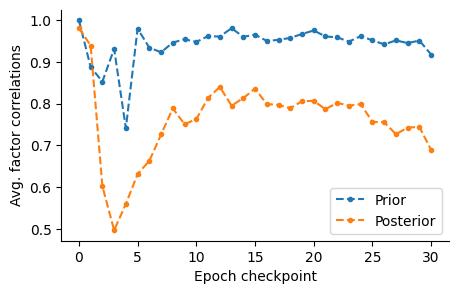

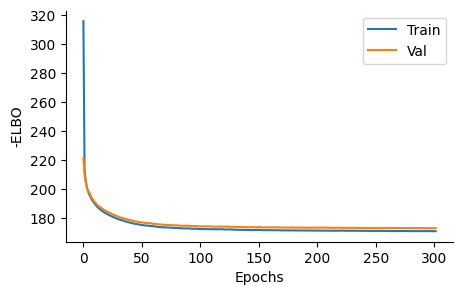

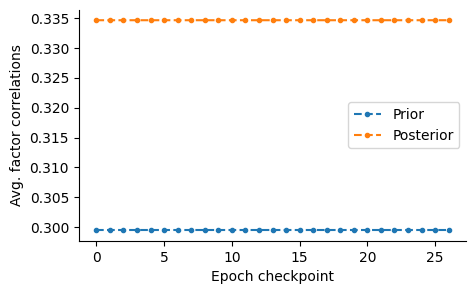

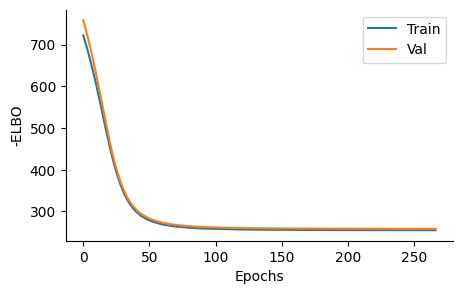

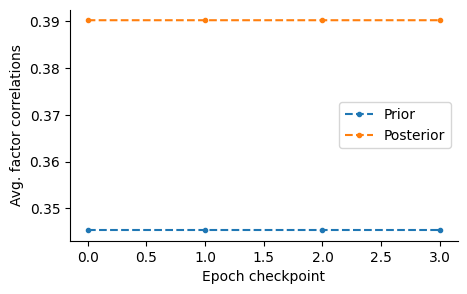

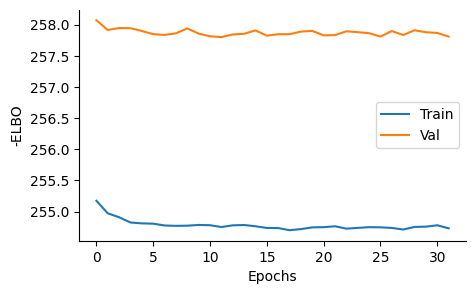

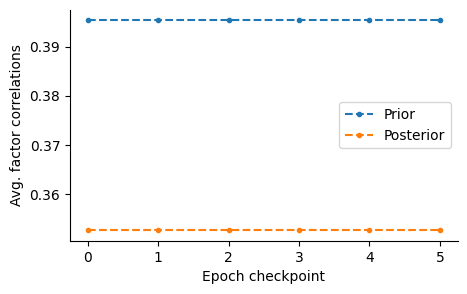

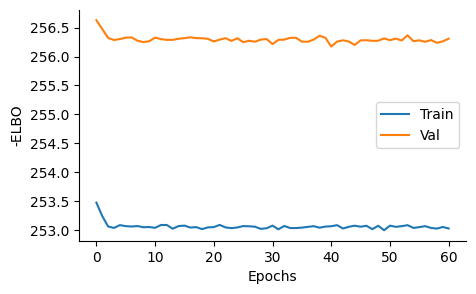

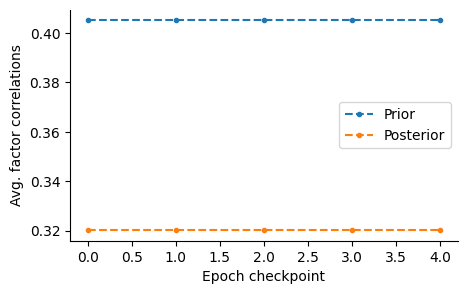

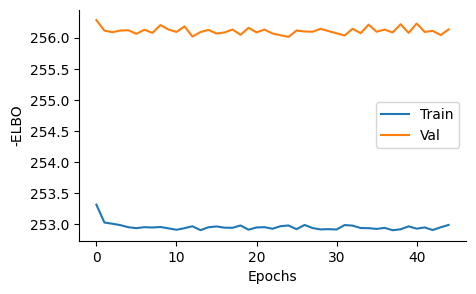

In [16]:
wandb.agent(sweep_id, function=main)

## Hyperparam Sweep 3/3/25

### Set wandb configs

In [ ]:
wandb.login()

In [ ]:
sweep_configuration = {
    "method": "grid",
    "name": "sweep",
    "metric": {"goal": "minimize", "name": "val_loss"},
    "parameters": {
        "graph_radius": {"values": [25, 50, 100]},
        "latent_dim": {"values": [4, 6, 8, 10, 12]},
        "lr": {"values": [1e-4, 1e-3, 1e-2]},
        "activation": {"values": ["SiLU", "ReLU", "LeakyReLU"]}
    },
}

In [ ]:
sweep_id = wandb.sweep(sweep=sweep_configuration, project="LYNX")

### Run Hyperparam Sweep

In [ ]:
def main():
    run = wandb.init()

    #### SET DATASET CONFIGS ####
    n_subgraphs = 16
    k = 100
    r = wandb.config.graph_radius
    sigma = 20
    
    graph_data = dataset.HeteroDataset(
        adatas_ref=adata_xenium, 
        adatas_query=adata_desi,
        n_subgraphs=n_subgraphs, 
        k=k,
        r=r,
        is_weighted=True,
        sigma=sigma,
        verbose=True
    )
    
    train_data, val_data = random_split(graph_data, [0.7, 0.3])
    train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

    #### SET MODEL CONFIGS ####

    # Model parameters
    n_hidden = 32
    n_latent = wandb.config.latent_dim
    act_dict = {"SiLU": nn.SiLU(), "ReLU": nn.ReLU(), "LeakyReLU": nn.LeakyReLU()}
    act = act_dict[wandb.config.activation]
    
    # Training parameters
    n_epochs = 500
    lr = wandb.config.lr
    patience = 20
    
    # Training & Inference
    train_configs = configs.set_train_configs(
        n_epochs=n_epochs, lr=lr, patience=patience, 
        device=torch.device('cuda'),
        anneal=False,
        verbose=True,
        #scheduler step and gamma applies gamma every step
        step_size=100, 
        gamma=0.1
    )
    
    model_configs = configs.set_model_configs(
        c_in=adata_xenium.shape[1],   # ref-dim 
        c_aux=adata_desi.shape[1],  # query-dim
        c_hidden=n_hidden, 
        c_latent=n_latent,
        act=act,
        ref=graph_data.ref, 
        query=graph_data.query,
        k_hop=1,
        num_heads=1,
        num_clusters=graph_data.num_clusters,
        verbose=True
    ) 

    # TRAIN
    model = vgae.HeteroVGAE(model_configs, device=torch.device('cuda'))
    model.fit(train_configs, train_dl=train_dl, val_dl=val_dl, DEBUG=True, log_wandb=True)

    del model, graph_data, train_data, val_data, train_dl, val_dl
    pyro.clear_param_store()
    torch.cuda.empty_cache()
    reload(vgae)

In [ ]:
wandb.agent(sweep_id, function=main)